# 05 — Validação em hardware quântico real (janelas IMDC)

Reexecuta o **VQR AngleEmbedding** em modo de **inferência** sobre a janela **T2 (surto de 2024, out/2023–set/2024)** do 2º IMDC, comparando três condições: (i) simulador exato (`default.qubit`), (ii) modelo de ruído IBM (`FakeBrisbane`) e (iii) QPU real **ibm_fez** (Heron r2, 156 qubits).

Os parâmetros são treinados no simulador com a janela de treino do T2 (jan/2022–out/2023) e **reutilizados sem reajuste** nas três condições, isolando o efeito do ruído.

> **Kernel:** use `qml_dengue (conda)`. Valide primeiro no simulador/ruído; só então cole o token e ative `RUN_ON_HARDWARE = True`.

In [1]:
# Dependências para hardware IBM — instala se necessário (idempotente).
# Necessário apenas para FakeBrisbane e para a execução em hardware real.
%pip install -q pennylane-qiskit qiskit-ibm-runtime
print("[OK] pacotes verificados. Se ACABOU de instalar agora, reinicie o kernel e rode tudo de novo.")

Note: you may need to restart the kernel to use updated packages.
[OK] pacotes verificados. Se ACABOU de instalar agora, reinicie o kernel e rode tudo de novo.


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os, sys, json, time, functools
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ─────────────────────────── CONFIGURAÇÃO ───────────────────────────
RUN_ON_HARDWARE = True          # <-- deixe False até validar no ruído/fake
IBM_TOKEN       = ''             # <-- cole aqui a API KEY da IBM Quantum (chave secreta, entre aspas)
IBM_INSTANCE    = ''             # <-- CRN da instância (nova IBM Quantum Platform), se sua conta exigir
JANELA     = 'T2'               # janela IMDC a avaliar (T2 = surto de 2024)
N_QUBITS   = 6
N_LAYERS   = 4
N_EPOCHS   = 80
LR         = 0.01
PATIENCE   = 15
N_SEMANAS  = 25                 # nº de semanas da janela a avaliar no hardware
SHOTS      = 2048
SEED       = 42
np.random.seed(SEED)
print(f'PennyLane {qml.__version__} | RUN_ON_HARDWARE={RUN_ON_HARDWARE} | janela={JANELA} | shots={SHOTS}')

PennyLane 0.42.3 | RUN_ON_HARDWARE=True | janela=T2 | shots=2048


In [3]:
# ── Dados: janela IMDC (via imdc_splits) ──
AQUI = os.path.abspath('..'); sys.path.insert(0, AQUI)
import imdc_splits as S
ds = S.carregar_dataset(); CEN = S.montar_cenarios(ds); d = CEN[JANELA]
X_tr, y_tr = d['X_train'], d['y_train']
X_te, y_te = d['X_test'],  d['y_test']
print(f'{JANELA}: treino={len(X_tr)} | teste={len(X_te)} | pico_teste={y_te.max():.0f}')
print('Descrição:', S.DESCRICAO[JANELA])

# Escala das 6 primeiras features para [0.01, pi] (mesmo protocolo do VQR AngleEmbedding)
sc_feat = MinMaxScaler(feature_range=(0.01, np.pi))
Xtr6 = sc_feat.fit_transform(X_tr[:, :N_QUBITS])
Xte6 = sc_feat.transform(X_te[:, :N_QUBITS])

T2: treino=88 | teste=52 | pico_teste=25714
Descrição: IMDC Teste 2 — surto recorde 2024  (out/2023 – set/2024)


In [4]:
# ── Circuito do VQR: AngleEmbedding + SEL + observável GLOBAL Z0..Z5 ──
OBS = functools.reduce(lambda a, b: a @ b, [qml.PauliZ(i) for i in range(N_QUBITS)])

def make_circuit(dev):
    @qml.qnode(dev)
    def circ(x, W):
        qml.AngleEmbedding(x[:N_QUBITS], wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(W, wires=range(N_QUBITS))
        return qml.expval(OBS)
    return circ

try:
    import pennylane_lightning  # noqa
    dev_train = qml.device('lightning.qubit', wires=N_QUBITS)
except ImportError:
    dev_train = qml.device('default.qubit', wires=N_QUBITS)
print(f'Device de treino: {dev_train.name}')

Device de treino: lightning.qubit


In [5]:
# ── Treino de UMA réplica do VQR na janela (simulador) ──
from copy import deepcopy
circ_train = make_circuit(dev_train)
y_log = np.log1p(y_tr).astype(float); mu_y, sig_y = y_log.mean(), y_log.std() + 1e-8
y_norm = (y_log - mu_y) / sig_y
Xb = pnp.array(Xtr6, requires_grad=False); yb = pnp.array(y_norm, requires_grad=False)
rng = np.random.RandomState(SEED)
W  = pnp.array(rng.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS, 3)) * 0.01, requires_grad=True)
sc = pnp.array(rng.uniform(0.5, 1.5), requires_grad=True); bi = pnp.array(0.0, requires_grad=True)
opt = qml.AdamOptimizer(LR)
best_loss, best, patc, t0 = float('inf'), None, 0, time.time()
for ep in range(N_EPOCHS):
    def cost(W_, sc_, bi_):
        preds = pnp.stack([circ_train(Xb[i], W_) * sc_ + bi_ for i in range(len(Xb))])
        return pnp.mean((preds - yb) ** 2)
    (W, sc, bi), loss = opt.step_and_cost(cost, W, sc, bi); lv = float(loss)
    if lv < best_loss: best_loss, best, patc = lv, (deepcopy(W.numpy()), float(sc), float(bi)), 0
    else:
        patc += 1
        if patc >= PATIENCE: break
    if ep % 10 == 0: print(f'  epoch {ep:3d} | loss={lv:.4f}')
W_star = pnp.array(best[0], requires_grad=False); sc_star, bi_star = best[1], best[2]
print(f'Treino concluído em {time.time()-t0:.0f}s | melhor loss={best_loss:.4f}')

  epoch   0 | loss=1.1778
  epoch  10 | loss=1.0823
  epoch  20 | loss=1.0055
  epoch  30 | loss=0.9517
  epoch  40 | loss=0.8959
  epoch  50 | loss=0.8196
  epoch  60 | loss=0.7329
  epoch  70 | loss=0.6476
Treino concluído em 118s | melhor loss=0.5697


In [6]:
# ── Funções de predição e avaliação ──
def predizer_circ(circ, X6, W, sc, bi, mu_y, sig_y, label=''):
    raw, t0 = [], time.time()
    for i, x in enumerate(X6):
        raw.append(float(circ(pnp.array(x, requires_grad=False), W)) * sc + bi)
        if label and (i + 1) % 10 == 0: print(f'    [{label}] {i+1}/{len(X6)}')
    preds = np.maximum(np.expm1(np.array(raw) * sig_y + mu_y), 0.0)
    if label: print(f'  [{label}] {len(X6)} circuitos em {time.time()-t0:.1f}s')
    return preds

def predizer(dev, X6, W, sc, bi, mu_y, sig_y, label=''):
    return predizer_circ(make_circuit(dev), X6, W, sc, bi, mu_y, sig_y, label)

def avaliar(y, p):
    return {'R2': r2_score(y, p), 'RMSE': float(np.sqrt(mean_squared_error(y, p))),
            'MAE': float(mean_absolute_error(y, p))}

In [7]:
# ── Seleciona ~25 semanas da janela (do vale ao pico) e roda o simulador exato ──
idx_sel = np.unique(np.linspace(0, len(Xte6) - 1, N_SEMANAS).astype(int))
Xsel = Xte6[idx_sel]; ysel = y_te[idx_sel]
print(f'Semanas selecionadas: {len(idx_sel)} | pico no subconjunto={ysel.max():.0f}')
dev_sim = qml.device('default.qubit', wires=N_QUBITS)
pred_sim = predizer(dev_sim, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label='simulador')
print('Simulador:', avaliar(ysel, pred_sim))

Semanas selecionadas: 25 | pico no subconjunto=25714
    [simulador] 10/25
    [simulador] 20/25
  [simulador] 25 circuitos em 0.5s
Simulador: {'R2': -0.37869869880813356, 'RMSE': 9523.675316355058, 'MAE': 5582.348966119566}


In [8]:
# ── Comparação com ruído: FakeBrisbane (IBM); se falhar, default.mixed (nativo) ──
pred_fake, fake_label = None, None; P_DEPOL = 0.01
try:
    from qiskit_ibm_runtime.fake_provider import FakeBrisbane
    fake = FakeBrisbane()
    dev_fake = qml.device('qiskit.remote', wires=N_QUBITS, backend=fake, shots=SHOTS)
    pred_fake = predizer(dev_fake, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label='fake-IBM')
    fake_label = 'Fake IBM (FakeBrisbane)'
except Exception as e:
    print('[AVISO] FakeBrisbane indisponível; plano B: ruído nativo default.mixed. Detalhe:', repr(e))
    dev_mixed = qml.device('default.mixed', wires=N_QUBITS)
    circ_noisy = qml.transforms.insert(make_circuit(dev_mixed), qml.DepolarizingChannel, P_DEPOL, position='all')
    pred_fake = predizer_circ(circ_noisy, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label='ruído')
    fake_label = f'Ruído nativo (default.mixed, depol p={P_DEPOL})'
print(f'{fake_label}:', avaliar(ysel, pred_fake))

    [fake-IBM] 10/25
    [fake-IBM] 20/25
  [fake-IBM] 25 circuitos em 97.0s
Fake IBM (FakeBrisbane): {'R2': -0.37634138782242155, 'RMSE': 9515.530001829848, 'MAE': 5626.3885669971805}


In [9]:
# ── Execução em hardware real (guardada por RUN_ON_HARDWARE) ──
pred_hw, backend_nome = None, None
if RUN_ON_HARDWARE:
    assert IBM_TOKEN, 'Cole a API KEY da IBM em IBM_TOKEN (célula de configuração, entre aspas).'
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel='ibm_cloud', token=IBM_TOKEN, instance=IBM_INSTANCE)
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_QUBITS)
    backend_nome = backend.name; print(f'Backend selecionado: {backend_nome}')
    dev_hw = qml.device('qiskit.remote', wires=N_QUBITS, backend=backend, shots=SHOTS)
    t0 = time.time()
    pred_hw = predizer(dev_hw, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label='hardware')
    print(f'Hardware ({backend_nome}):', avaliar(ysel, pred_hw))
    print(f'Tempo total do job: {time.time()-t0:.0f}s (wall-clock, inclui fila)')
else:
    print('RUN_ON_HARDWARE=False — pulando execução real. Ative após validar no ruído/fake.')

Backend selecionado: ibm_fez
    [hardware] 10/25
    [hardware] 20/25
  [hardware] 25 circuitos em 877.3s
Hardware (ibm_fez): {'R2': -0.3773536681526082, 'RMSE': 9519.028629956061, 'MAE': 5597.230459204315}
Tempo total do job: 877s (wall-clock, inclui fila)


In [10]:
# ── Tabela comparativa ──
linhas = [('Simulador (default.qubit)', pred_sim)]
if pred_fake is not None: linhas.append((fake_label, pred_fake))
if pred_hw   is not None: linhas.append((f'Hardware ({backend_nome})', pred_hw))
print(f"{'Condição':<40}{'R2':>10}{'RMSE':>12}{'MAE':>12}")
print('-' * 74); resumo = {}
for nome, p in linhas:
    m = avaliar(ysel, p); resumo[nome] = m
    print(f'{nome:<40}{m["R2"]:>10.4f}{m["RMSE"]:>12.1f}{m["MAE"]:>12.1f}')

Condição                                        R2        RMSE         MAE
--------------------------------------------------------------------------
Simulador (default.qubit)                  -0.3787      9523.7      5582.3
Fake IBM (FakeBrisbane)                    -0.3763      9515.5      5626.4
Hardware (ibm_fez)                         -0.3774      9519.0      5597.2


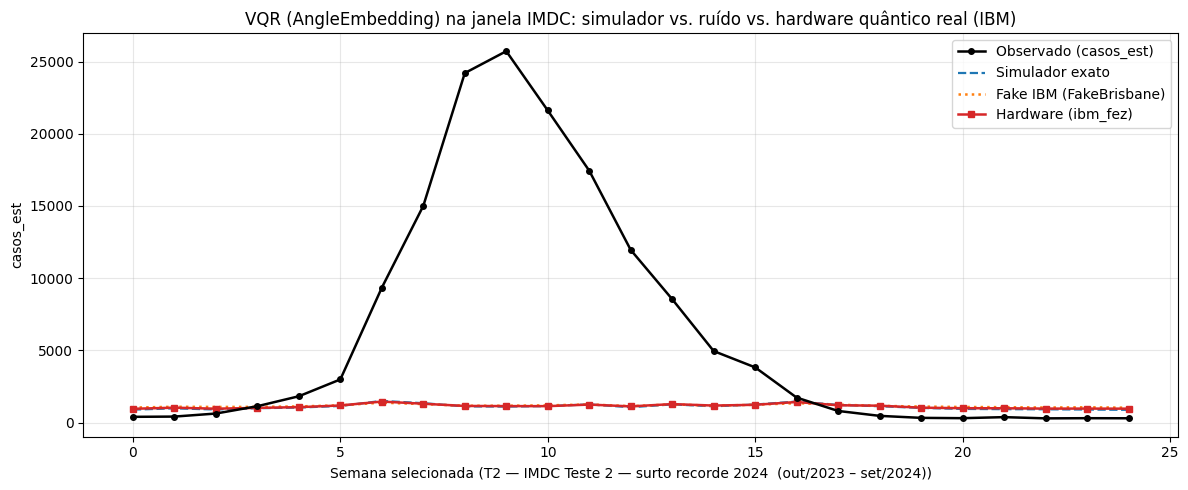

[SALVO] c:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\hardware_vqr_T2.png
[SALVO] c:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\resultados\hardware_vqr_T2_resultados.json


In [11]:
# ── Figura + salvamento (em ../figuras e ../resultados) ──
FIG = os.path.join(AQUI, 'figuras'); RES = os.path.join(AQUI, 'resultados')
x = np.arange(len(idx_sel))
plt.figure(figsize=(12, 5))
plt.plot(x, ysel, 'k-o', lw=1.8, ms=4, label='Observado (casos_est)', zorder=6)
plt.plot(x, pred_sim, '--', color='tab:blue', lw=1.6, label='Simulador exato')
if pred_fake is not None: plt.plot(x, pred_fake, ':', color='tab:orange', lw=1.8, label=fake_label)
if pred_hw is not None: plt.plot(x, pred_hw, '-', color='tab:red', lw=1.8, marker='s', ms=4, label=f'Hardware ({backend_nome})')
plt.xlabel(f'Semana selecionada ({JANELA} — {S.DESCRICAO[JANELA]})'); plt.ylabel('casos_est')
plt.title('VQR (AngleEmbedding) na janela IMDC: simulador vs. ruído vs. hardware quântico real (IBM)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
fp = os.path.join(FIG, f'hardware_vqr_{JANELA}.png'); plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()
saida = {'modelo': 'VQR_AngleEmbedding', 'janela': JANELA, 'descricao': S.DESCRICAO[JANELA],
         'n_semanas': int(len(idx_sel)), 'shots': SHOTS, 'backend': backend_nome,
         'executado_em_hardware': bool(RUN_ON_HARDWARE),
         'metricas': {k: {kk: round(float(vv), 4) for kk, vv in v.items()} for k, v in resumo.items()},
         'indices_semanas': [int(i) for i in idx_sel]}
with open(os.path.join(RES, f'hardware_vqr_{JANELA}_resultados.json'), 'w', encoding='utf-8') as f:
    json.dump(saida, f, indent=2, ensure_ascii=False)
print('[SALVO]', fp); print('[SALVO]', os.path.join(RES, f'hardware_vqr_{JANELA}_resultados.json'))